In [1]:
import numpy as np
import matplotlib.pyplot as plt
from src.aero_block import AeroBlock

# Load both wing and elevator blocks
aero_wing = AeroBlock.from_ckpt(
    "artifacts/models/3d_blocks.pt",
    part="wing",
    mode="implicit",  # or "explicit"
    device="cpu"
)

aero_elevator = AeroBlock.from_ckpt(
    "artifacts/models/3d_blocks.pt",
    part="elevator",
    mode="implicit",
    device="cpu"
)

# Reference areas (TODO: Update with actual values)
S_wing = 0.238      # m² - Wing reference area
S_elev = 0.021     # m² - Elevator reference area (typical ~15% of wing area)

# Moment arm lengths for elevator contribution to total CM
# Distance from wing aerodynamic center to elevator aerodynamic center
x_arm = 0.6275      # m - Horizontal distance (positive aft) - TODO: Update
z_arm = 0.156-(-0.004)       # m - Vertical distance (positive up) - TODO: Update

# Define sweep parameters
V_cruise = 50.0  # m/s (fixed velocity)
alpha_range = np.arange(-10, 11, 1)  # degrees

# Storage for results
results = {
    "alpha": alpha_range,
    "wing": {"CL": [], "CD": [], "CM": []},
    "elevator": {"CL": [], "CD": [], "CM": []},
    "total": {"CL": [], "CD": [], "CM": []}
}

print(f"Computing coefficients at V = {V_cruise} m/s...")
print(f"Reference areas: S_wing = {S_wing} m², S_elev = {S_elev} m²")
print(f"Elevator moment arms: x = {x_arm} m, z = {z_arm} m")
print()

# Sweep through angles of attack
for alpha in alpha_range:
    # Wing contributions (referenced to S_wing)
    wing_coeffs = aero_wing.forward(alpha, V_cruise)
    results["wing"]["CL"].append(wing_coeffs["CL"])
    results["wing"]["CD"].append(wing_coeffs["CD"])
    results["wing"]["CM"].append(wing_coeffs["CM"])
    
    # Elevator contributions (referenced to S_elev)
    elev_coeffs = aero_elevator.forward(alpha, V_cruise)
    results["elevator"]["CL"].append(elev_coeffs["CL"])
    results["elevator"]["CD"].append(elev_coeffs["CD"])
    results["elevator"]["CM"].append(elev_coeffs["CM"])
    
    # Total aircraft coefficients (referenced to S_wing)
    # CL_total = (CL_wing * S_wing + CL_elev * S_elev) / S_wing
    CL_total = wing_coeffs["CL"] + elev_coeffs["CL"] * (S_elev / S_wing)
    
    # CD_total = (CD_wing * S_wing + CD_elev * S_elev) / S_wing
    CD_total = wing_coeffs["CD"] + elev_coeffs["CD"] * (S_elev / S_wing)
    
    # CM_total = CM_wing + CM_elev * (S_elev/S_wing) 
    #            + CL_elev * (S_elev/S_wing) * (x_arm/c_wing)
    #            - CD_elev * (S_elev/S_wing) * (z_arm/c_wing)
    # For now using c_wing = 1.0 as placeholder (you can update later)
    c_wing = 1.0  # m - Wing mean aerodynamic chord - TODO: Update
    
    CM_total = (wing_coeffs["CM"] + 
                elev_coeffs["CM"] * (S_elev / S_wing) +
                elev_coeffs["CL"] * (S_elev / S_wing) * (x_arm / c_wing) -
                elev_coeffs["CD"] * (S_elev / S_wing) * (z_arm / c_wing))
    
    results["total"]["CL"].append(CL_total)
    results["total"]["CD"].append(CD_total)
    results["total"]["CM"].append(CM_total)

# Convert to numpy arrays for easier plotting
for part in ["wing", "elevator", "total"]:
    for coeff in ["CL", "CD", "CM"]:
        results[part][coeff] = np.array(results[part][coeff])

print("✓ Computation complete!")


/Users/gherardi/Documents/GitHub/GliderProject_Aero_ROM/refactoring/aero_rom/src/llt.py:68: UserWarning: Airfoil dpspencerk60 had no coordinates assigned, and could not parse the `coordinates` input!
  airfoil_asb = asb.Airfoil(normalized_name).to_kulfan_airfoil()
/opt/anaconda3/envs/general/lib/python3.12/site-packages/aerosandbox/geometry/airfoil/airfoil_families.py:481: UserWarning: Airfoil Target Airfoil had no coordinates assigned, and could not parse the `coordinates` input!
  Airfoil(name="Target Airfoil", coordinates=coordinates)


✓ Loading 'DP_Spencer_K60' from custom CST: /Users/gherardi/Documents/GitHub/GliderProject_Aero_ROM/refactoring/aero_rom/data/DP_Spencer_K60_CST.json
✓ Loaded 'NACA_0012' from AeroSandbox database
✓ Loading 'DP_Spencer_K60' from custom CST: /Users/gherardi/Documents/GitHub/GliderProject_Aero_ROM/refactoring/aero_rom/data/DP_Spencer_K60_CST.json
✓ Loaded 'NACA_0012' from AeroSandbox database
Computing coefficients at V = 50.0 m/s...
Reference areas: S_wing = 0.238 m², S_elev = 0.021 m²
Elevator moment arms: x = 0.6275 m, z = 0.16 m

✓ Computation complete!


## Tables

In [2]:
import pandas as pd

print(f"\nAIRCRAFT AERODYNAMIC COEFFICIENTS - V∞ = {V_cruise:.1f} m/s")
print("="*80)

# Wing coefficients
print(f"\nWING COEFFICIENTS (referenced to S_wing = {S_wing:.4f} m²)")
df_wing = pd.DataFrame({
    "α [deg]": results["alpha"],
    "CL": results["wing"]["CL"],
    "CD": results["wing"]["CD"],
    "CM": results["wing"]["CM"],
})
print(df_wing.to_string(index=False))

# Elevator coefficients
print(f"\nELEVATOR COEFFICIENTS (referenced to S_elev = {S_elev:.4f} m²)")
df_elev = pd.DataFrame({
    "α [deg]": results["alpha"],
    "CL": results["elevator"]["CL"],
    "CD": results["elevator"]["CD"],
    "CM": results["elevator"]["CM"],
})
print(df_elev.to_string(index=False))

# Total aircraft coefficients
print(f"\nTOTAL AIRCRAFT COEFFICIENTS (referenced to S_wing = {S_wing:.4f} m²)")
df_total = pd.DataFrame({
    "α [deg]": results["alpha"],
    "CL": results["total"]["CL"],
    "CD": results["total"]["CD"],
    "CM": results["total"]["CM"],
})
print(df_total.to_string(index=False))

print("\n" + "="*80)


AIRCRAFT AERODYNAMIC COEFFICIENTS - V∞ = 50.0 m/s

WING COEFFICIENTS (referenced to S_wing = 0.2380 m²)
 α [deg]        CL       CD        CM
     -10 -0.651936 0.056568 -0.118042
      -9 -0.639998 0.039812 -0.110660
      -8 -0.564039 0.028271 -0.101761
      -7 -0.467318 0.021770 -0.093100
      -6 -0.374992 0.017624 -0.084028
      -5 -0.283762 0.014654 -0.074367
      -4 -0.197737 0.011512 -0.064174
      -3 -0.120568 0.009093 -0.052559
      -2 -0.022781 0.008739 -0.042072
      -1  0.085456 0.009105 -0.033333
       0  0.203804 0.009785 -0.025919
       1  0.327023 0.010773 -0.019190
       2  0.454629 0.012234 -0.013254
       3  0.583787 0.014323 -0.007933
       4  0.705204 0.016965 -0.002053
       5  0.801112 0.019984  0.006618
       6  0.854424 0.023483  0.019993
       7  0.886077 0.027024  0.036967
       8  0.912045 0.030370  0.054385
       9  0.935811 0.033807  0.071044
      10  0.968856 0.037984  0.085487

ELEVATOR COEFFICIENTS (referenced to S_elev = 0.0210 m²)
 

## Plots

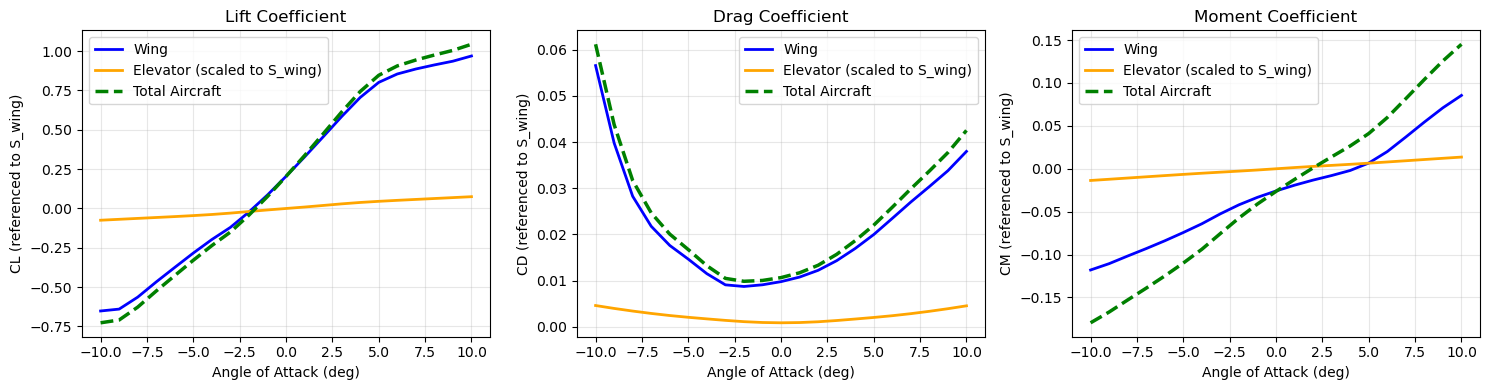

In [3]:
# Plot CL, CD, CM for wing, elevator (scaled), and total aircraft
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

coeffs = ["CL", "CD", "CM"]
titles = ["Lift Coefficient", "Drag Coefficient", "Moment Coefficient"]
colors = {"wing": "blue", "elevator": "orange", "total": "green"}

for ax, coeff, title in zip(axes, coeffs, titles):
    # Plot wing coefficients (referenced to S_wing)
    ax.plot(results["alpha"], results["wing"][coeff], 
            label="Wing", color=colors["wing"], linewidth=2)
    
    # Plot elevator coefficients scaled to wing reference area
    elev_scaled = results["elevator"][coeff] * (S_elev / S_wing)
    ax.plot(results["alpha"], elev_scaled, 
            label=f"Elevator (scaled to S_wing)", color=colors["elevator"], linewidth=2)
    
    # Plot total aircraft coefficients
    ax.plot(results["alpha"], results["total"][coeff], 
            label="Total Aircraft", color=colors["total"], linewidth=2.5, linestyle="--")
    
    ax.set_xlabel("Angle of Attack (deg)")
    ax.set_ylabel(f"{coeff} (referenced to S_wing)")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.savefig("aircraft_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()

## Specific angle of attack

In [4]:
# Detailed breakdown at specific angle of attack
alpha_inspect = 5.0

wing_at_5 = aero_wing.forward(alpha_inspect, V_cruise)
elev_at_5 = aero_elevator.forward(alpha_inspect, V_cruise)

# Compute total with scaling
CL_total = wing_at_5["CL"] + elev_at_5["CL"] * (S_elev / S_wing)
CD_total = wing_at_5["CD"] + elev_at_5["CD"] * (S_elev / S_wing)
CM_total = (wing_at_5["CM"] + 
            elev_at_5["CM"] * (S_elev / S_wing) +
            elev_at_5["CL"] * (S_elev / S_wing) * (x_arm / c_wing) -
            elev_at_5["CD"] * (S_elev / S_wing) * (z_arm / c_wing))

print(f"\n{'='*70}")
print(f"Coefficient Breakdown at α = {alpha_inspect}°, V = {V_cruise} m/s")
print(f"(All coefficients referenced to S_wing = {S_wing} m²)")
print(f"{'='*70}")
print(f"{'Component':<20} {'CL':>12} {'CD':>12} {'CM':>12}")
print(f"{'-'*70}")
print(f"{'Wing':<20} {wing_at_5['CL']:>12.6f} {wing_at_5['CD']:>12.6f} {wing_at_5['CM']:>12.6f}")
print(f"{'Elevator (raw)':<20} {elev_at_5['CL']:>12.6f} {elev_at_5['CD']:>12.6f} {elev_at_5['CM']:>12.6f}")
print(f"{'Elevator (scaled)':<20} {elev_at_5['CL']*(S_elev/S_wing):>12.6f} "
      f"{elev_at_5['CD']*(S_elev/S_wing):>12.6f} "
      f"{elev_at_5['CM']*(S_elev/S_wing):>12.6f}")
print(f"{'-'*70}")
print(f"{'Total Aircraft':<20} {CL_total:>12.6f} {CD_total:>12.6f} {CM_total:>12.6f}")
print(f"{'='*70}\n")

print("Reference parameters (TODO: Update these):")
print(f"  S_wing = {S_wing} m²")
print(f"  S_elev = {S_elev} m²")
print(f"  c_wing = {c_wing} m")
print(f"  x_arm  = {x_arm} m (horizontal distance to elevator)")
print(f"  z_arm  = {z_arm} m (vertical distance to elevator)")


Coefficient Breakdown at α = 5.0°, V = 50.0 m/s
(All coefficients referenced to S_wing = 0.238 m²)
Component                      CL           CD           CM
----------------------------------------------------------------------
Wing                     0.801112     0.019984     0.006618
Elevator (raw)           0.510342     0.023029     0.073341
Elevator (scaled)        0.045030     0.002032     0.006471
----------------------------------------------------------------------
Total Aircraft           0.846142     0.022016     0.041021

Reference parameters (TODO: Update these):
  S_wing = 0.238 m²
  S_elev = 0.021 m²
  c_wing = 1.0 m
  x_arm  = 0.6275 m (horizontal distance to elevator)
  z_arm  = 0.16 m (vertical distance to elevator)


## Save to .csv

In [5]:
# Save results to CSV with both raw and scaled values
import pandas as pd
import os


df = pd.DataFrame({
    "alpha_deg": results["alpha"],
    # Wing coefficients (referenced to S_wing)
    "wing_CL": results["wing"]["CL"],
    "wing_CD": results["wing"]["CD"],
    "wing_CM": results["wing"]["CM"],
    # Elevator raw coefficients (referenced to S_elev)
    "elev_CL_raw": results["elevator"]["CL"],
    "elev_CD_raw": results["elevator"]["CD"],
    "elev_CM_raw": results["elevator"]["CM"],
    # Elevator scaled coefficients (referenced to S_wing)
    "elev_CL_scaled": results["elevator"]["CL"] * (S_elev / S_wing),
    "elev_CD_scaled": results["elevator"]["CD"] * (S_elev / S_wing),
    "elev_CM_scaled": results["elevator"]["CM"] * (S_elev / S_wing),
    # Total aircraft coefficients (referenced to S_wing)
    "total_CL": results["total"]["CL"],
    "total_CD": results["total"]["CD"],
    "total_CM": results["total"]["CM"],
})

df.to_csv(os.path.join(os.getcwd(),'artifacts','results', "aircraft_coefficients.csv"), index=False)
print("✓ Results saved to aircraft_coefficients.csv")
df.head(10)

✓ Results saved to aircraft_coefficients.csv


,alpha_deg,wing_CL,wing_CD,wing_CM,elev_CL_raw,elev_CD_raw,elev_CM_raw,elev_CL_scaled,elev_CD_scaled,elev_CM_scaled,total_CL,total_CD,total_CM
0,-10,-0.651936,0.056568,-0.118042,-0.851152,0.052315,-0.155245,-0.075102,0.004616,-0.013698,-0.727038,0.061184,-0.179605
1,-9,-0.639998,0.039812,-0.110660,-0.784892,0.045173,-0.139197,-0.069255,0.003986,-0.012282,-0.709253,0.043798,-0.167038
2,-8,-0.564039,0.028271,-0.101761,-0.719517,0.038713,-0.122963,-0.063487,0.003416,-0.010850,-0.627526,0.031687,-0.152995
3,-7,-0.467318,0.021770,-0.093100,-0.654164,0.032886,-0.106733,-0.057720,0.002902,-0.009418,-0.525038,0.024671,-0.139202
4,-6,-0.374992,0.017624,-0.084028,-0.588170,0.027769,-0.090638,-0.051897,0.002450,-0.007997,-0.426889,0.020075,-0.124983
5,-5,-0.283762,0.014654,-0.074367,-0.517636,0.023409,-0.074741,-0.045674,0.002066,-0.006595,-0.329436,0.016720,-0.109952
6,-4,-0.197737,0.011512,-0.064174,-0.437122,0.019527,-0.059534,-0.038570,0.001723,-0.005253,-0.236306,0.013235,-0.093905
7,-3,-0.120568,0.009093,-0.052559,-0.338604,0.015851,-0.045435,-0.029877,0.001399,-0.004009,-0.150445,0.010491,-0.075540
8,-2,-0.022781,0.008739,-0.042072,-0.223995,0.012705,-0.031691,-0.019764,0.001121,-0.002796,-0.042546,0.009860,-0.057450
9,-1,0.085456,0.009105,-0.033333,-0.110847,0.010669,-0.016835,-0.009781,0.000941,-0.001485,0.075675,0.010046,-0.041106


/Users/gherardi/Documents/GitHub/GliderProject_Aero_ROM/refactoring/aero_rom/src/llt.py:68: UserWarning: Airfoil dpspencerk60 had no coordinates assigned, and could not parse the `coordinates` input!
  airfoil_asb = asb.Airfoil(normalized_name).to_kulfan_airfoil()
/opt/anaconda3/envs/general/lib/python3.12/site-packages/aerosandbox/geometry/airfoil/airfoil_families.py:481: UserWarning: Airfoil Target Airfoil had no coordinates assigned, and could not parse the `coordinates` input!
  Airfoil(name="Target Airfoil", coordinates=coordinates)


✓ Loading 'DP_Spencer_K60' from custom CST: /Users/gherardi/Documents/GitHub/GliderProject_Aero_ROM/refactoring/aero_rom/data/DP_Spencer_K60_CST.json
Converged after 18 iterations
Max |Gamma_state - 0.5 V c cl_final| = 5.511073223551932e-06
Mean |...| = 2.3268669705222267e-06
Saved figure to: /Users/gherardi/Documents/GitHub/GliderProject_Aero_ROM/refactoring/aero_rom/artifacts/images/config_DynaSoar_wing_aoa6.00deg_V50.00ms_unscaled.png


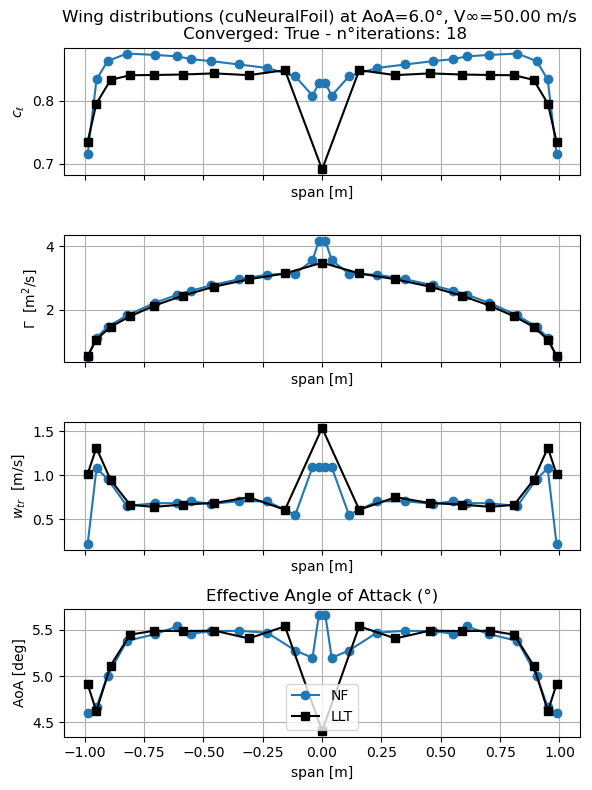

In [47]:
# ============================================================
# Wing spanwise distributions using cuNeuralFoil (self-contained)
# ============================================================

import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch
import pandas as pd

from src.config import load_config
from src.llt import LLT_computational_params
from cuneuralfoil.cu_kulfan_airfoil import cuKulfanAirfoil
from cuneuralfoil.main import get_aero_from_kulfan_parameters_cuda

# ----------------------------
# 0) Locate project root
# ----------------------------
def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for p in [start] + list(start.parents):
        if (p / "data" / "config_DynaSoar.json").exists() and (p / "src").exists():
            return p
    raise FileNotFoundError("Could not find project root containing data/config_DynaSoar.json and src/")

ROOT = find_project_root(Path.cwd())
CFG_PATH = ROOT / "data" / "config_DynaSoar.json"

# ----------------------------
# 1) Load config + flow dict
# ----------------------------
cfg = load_config(str(CFG_PATH))

rho = float(cfg["flow"]["rho"])
nu  = float(cfg["flow"]["nu"])
mu  = rho * nu

airflow = {
    "rho": rho,
    "nu": nu,
    "mu": mu,
    "R": float(cfg["flow"].get("R", 287.058)),
    "T": float(cfg["flow"].get("T", 288.15)),
    "p": float(cfg["flow"].get("p", 101325.0)),
}

# ----------------------------
# 2) Build wing computation params
#    (prefer *_extra if present for nicer distributions)
# ----------------------------
wg = cfg["wing_geometry"]

y_half    = wg.get("y_half_extra",    wg["y_half"])
c_half    = wg.get("c_half_extra",    wg["c_half"])
xle_half  = wg.get("xle_half_extra",  wg["xle_half"])
twist_half= wg.get("twist_half_extra",wg["twist_half"])
airfoil_name = wg["airfoil"]

comp_wing = LLT_computational_params(
    y_half=y_half,
    c_half=c_half,
    xle_half=xle_half,
    twist_half=twist_half,
    airfoil_name=airfoil_name
)

y_mid = comp_wing["y_mid"]

# ----------------------------
# 3) cuNeuralFoil setup
# ----------------------------
device = cfg.get("device", "cuda")
model_size = cfg.get("model_size", "xlarge")

# cuNeuralFoil is CUDA-oriented; guard explicitly
if device == "cuda" and not torch.cuda.is_available():
    raise RuntimeError("device='cuda' requested in config, but torch.cuda.is_available() is False.")

airfoil_cu = cuKulfanAirfoil(
    comp_wing["airfoil_CST"],
    device=device,
    requires_grad=False,
)

# ----------------------------
# 4) One-shot LLT iterative solve returning distributions
#    (matches src/llt.py::run_llt_cuNF_grid logic but for one AoA, one V)
# ----------------------------
def solve_iterative_cuNF_distribution(
    aoa_deg: float,
    V_inf: float,
    airflow: dict,
    computation_params: dict,
    airfoil_cu,
    n_iter: int = 50,
    beta: float = 0.40,
    tol: float = 1e-6,
    enforce_symmetry: bool = True,
    device: str = "cuda",
    model_size: str = "xlarge",
):
    dy   = computation_params["dy"]
    y    = computation_params["y_mid"]
    c    = computation_params["c_mid"]
    tw   = computation_params["tw_mid"]
    D_nf = computation_params["D_nf"]
    D_tr = computation_params["D_tr"]
    mirror_of = computation_params["mirror_of"]

    rho = float(airflow["rho"])
    mu  = float(airflow["mu"])

    alpha_geo = aoa_deg + tw
    Re_panels = rho * V_inf * c / mu

    # --- eval_nf: exactly the same batching pattern as run_llt_cuNF_grid ---
    def eval_nf(alpha_deg_panels, Re_panels):
        B = alpha_deg_panels.shape[0]

        upper_base = airfoil_cu.upper_weights_cuda
        lower_base = airfoil_cu.lower_weights_cuda
        LE_base    = airfoil_cu.leading_edge_weight_cuda
        TE_base    = airfoil_cu.TE_thickness_cuda

        kulfan_batch = {
            "upper_weights_cuda": upper_base.unsqueeze(0).repeat(B, 1),
            "lower_weights_cuda": lower_base.unsqueeze(0).repeat(B, 1),
            "leading_edge_weight_cuda": LE_base.repeat(B),
            "TE_thickness_cuda": TE_base.repeat(B),
        }

        alpha_t = torch.as_tensor(alpha_deg_panels, dtype=torch.float32, device=device)
        Re_t    = torch.as_tensor(Re_panels,       dtype=torch.float32, device=device)

        with torch.no_grad():
            aero_t = get_aero_from_kulfan_parameters_cuda(
                kulfan_batch,
                alpha_t,
                Re_t,
                device=device,
                model_size=model_size,
            )

        out = {}
        for k, v in aero_t.items():
            out[k] = v.detach().cpu().numpy() if isinstance(v, torch.Tensor) else np.asarray(v)
        return out

    # Initial guess
    aero0 = eval_nf(alpha_geo, Re_panels)
    cl0   = aero0["CL"]
    Gamma = 0.5 * V_inf * c * cl0

    def apply_D(mat, gamma):
        return gamma @ mat.T
    converged=False
    # Picard iteration using near-field downwash
    for _ in range(n_iter):
        w_nf = apply_D(D_nf, Gamma)
        alpha_eff_iter = alpha_geo - np.degrees(np.arctan2(w_nf, V_inf))

        aer = eval_nf(alpha_eff_iter, Re_panels)
        cl_star = aer["CL"]
        Gamma_star = 0.5 * V_inf * c * cl_star

        Gamma_new = (1.0 - beta) * Gamma + beta * Gamma_star

        if enforce_symmetry:
            j = mirror_of
            Gamma_new = 0.5 * (Gamma_new + Gamma_new[j])

        diff = np.max(np.abs(Gamma_new - Gamma))
        if diff < tol * max(1.0, float(np.max(np.abs(Gamma)))):
            Gamma = Gamma_new
            print(f"Converged after {_} iterations")
            converged=True
            break

        Gamma = Gamma_new

    # Final (Trefftz) downwash + final effective alpha
    w_nf = apply_D(D_nf, Gamma)
    w_tr = apply_D(D_tr, Gamma)
    alpha_eff = alpha_geo - np.degrees(np.arctan2(w_nf, V_inf))

    aer_final = eval_nf(alpha_eff, Re_panels)
    cl = aer_final["CL"]
    # cl = cl_star   # from the final iteration
    # alpha_eff = alpha_eff_iter
    return {
        "y_mid": y,
        "cl": cl,
        "Gamma": Gamma,
        "w_nf": w_nf,
        "w_tr": w_tr,
        "alpha_geo": alpha_geo,
        "alpha_eff": alpha_eff,
        "Re": Re_panels,
        "convergence": converged,
        "iterations": _
    }

# ----------------------------
# 5) Choose AoA and V_inf and plot
# ----------------------------
aoa_show = 6.0  # deg

# choose a representative speed:
# if your notebook has V_cruise defined earlier, it will use it; otherwise use config midrange.
V_inf_show = 50.0

res = solve_iterative_cuNF_distribution(
    aoa_deg=aoa_show,
    V_inf=V_inf_show,
    airflow=airflow,
    computation_params=comp_wing,
    airfoil_cu=airfoil_cu,
    n_iter=50,
    beta=cfg.get("beta", 0.40),
    tol=cfg.get("tol", 1e-6),
    enforce_symmetry=cfg.get("enforce_symmetry", True),
    device=device,
    model_size=model_size,
)

y_mid = res["y_mid"]
c_mid = comp_wing["c_mid"]
Gamma_from_cl_tr = 0.5 * V_inf_show * c_mid * res["cl"]

err = res["Gamma"] - Gamma_from_cl_tr
print("Max |Gamma_state - 0.5 V c cl_final| =", np.max(np.abs(err)))
print("Mean |...| =", np.mean(np.abs(err)))

csv_path_flow5LLT=os.path.join(os.getcwd(), 'artifacts', 'results', '5-5-Wing_a=6.00_v=50.00ms_Reduced_LLT_v2.csv')
f5LLT_df = pd.read_csv(csv_path_flow5LLT)
alpha_eff_f5 = aoa_show - np.degrees(np.arctan2(-f5LLT_df["Vd.z"], V_inf_show))

neuralfoil_alpha_eff= res['alpha_geo'] - np.degrees(np.arctan2(res["w_nf"], V_inf_show))

# Flow5 y locations
y_f5 = f5LLT_df["y(m)"].to_numpy(dtype=float)
Cl_f5 = f5LLT_df["Cl"].to_numpy(dtype=float)

# Interpolate chord from your wing geometry onto flow5 stations (assume symmetry)
y_ref = np.abs(comp_wing["y_mid"].astype(float))
c_ref = comp_wing["c_mid"].astype(float)

# Make sure the ref arrays are sorted for np.interp
idx_sort = np.argsort(y_ref)
y_ref_s = y_ref[idx_sort]
c_ref_s = c_ref[idx_sort]

c_f5 = np.interp(np.abs(y_f5), y_ref_s, c_ref_s)

# Circulation from flow5 Cl
Gamma_f5_from_Cl = 0.5 * V_inf_show * c_f5 * Cl_f5
f5LLT_df["Gamma_from_Cl"]=Gamma_f5_from_Cl

Gamma_nf_from_cl = 0.5 * V_inf_show * comp_wing["c_mid"] * res["cl"]

cl_nf_from_Gamma=res["Gamma"]/(0.5*V_inf_show * comp_wing["c_mid"])

fig, axs = plt.subplots(4, 1, figsize=(6,8), sharex=True)

axs[0].plot(y_mid, res["cl"], "-o")
#axs[0].plot(y_mid, cl_nf_from_Gamma, "-x")
axs[0].plot(f5LLT_df["y(m)"], f5LLT_df["Cl"], '-s', color='black',label="LLT")
axs[0].set_title(f"Wing distributions (cuNeuralFoil) at AoA={aoa_show:.1f}°, V∞={V_inf_show:.2f} m/s \n Converged: {res['convergence']} - n°iterations: {res['iterations']}")
axs[0].set_ylabel(r"$c_\ell$")
axs[0].set_xlabel('span [m]')
axs[0].grid(True)

axs[1].plot(y_mid, res["Gamma"], "-o")
#axs[1].plot(y_mid, Gamma_nf_from_cl, "-x", label="NF Γ from cl")
axs[1].plot(f5LLT_df["y(m)"], Gamma_f5_from_Cl, '-s', color='black',label="LLT")
axs[1].set_ylabel(r"$\Gamma$  [m$^2$/s]")
axs[1].set_xlabel('span [m]')
axs[1].grid(True)

axs[2].plot(y_mid, res["w_tr"], "-o")
axs[2].plot(f5LLT_df["y(m)"], -f5LLT_df["Vd.z"], '-s', color='black',label="LLT")
axs[2].set_ylabel(r"$w_{tr}$  [m/s]")
axs[2].set_xlabel("Spanwise location y [m]")
axs[2].set_xlabel('span [m]')
axs[2].grid(True)

# effective AoA comparison

axs[3].plot(y_mid, res["alpha_eff"], "-o",label="NF")
axs[3].plot(f5LLT_df["y(m)"],f5LLT_df["alpha_eff"],'-s', color='black',label="LLT")

axs[3].set_title("Effective Angle of Attack (°)")
axs[3].set_xlabel("span [m]")
axs[3].set_ylabel("AoA [deg]")
axs[3].grid(True)
axs[3].legend()


plt.tight_layout()
artifacts_dir = ROOT / "artifacts" / "images"
artifacts_dir.mkdir(parents=True, exist_ok=True)

json_name = Path(CFG_PATH).stem        # e.g. "config"
part_name = "wing"
aoa_str   = f"{aoa_show:.2f}deg"
vel_str   = f"{V_inf_show:.2f}ms"

fig_name = f"{json_name}_{part_name}_aoa{aoa_str}_V{vel_str}_unscaled.png"
fig_path = artifacts_dir / fig_name

plt.savefig(fig_path, dpi=200, bbox_inches="tight")
print(f"Saved figure to: {fig_path}")
plt.show()


In [ ]:

# ----------------------------
# Save figure to artifacts/images
# ----------------------------
artifacts_dir = ROOT / "artifacts" / "images"
artifacts_dir.mkdir(parents=True, exist_ok=True)

json_name = Path(CFG_PATH).stem        # e.g. "config"
part_name = "wing"

aoa_show_range=np.arange(10, 190, 10)
for aoa_show_inc in aoa_show_range:

    res = solve_iterative_cuNF_distribution(
    aoa_deg=aoa_show_inc,
    V_inf=V_inf_show,
    airflow=airflow,
    computation_params=comp_wing,
    airfoil_cu=airfoil_cu,
    n_iter=1000,
    beta=cfg.get("beta", 0.40),
    tol=cfg.get("tol", 1e-6),
    enforce_symmetry=cfg.get("enforce_symmetry", True),
    device=device,
    model_size=model_size,
    )
    fig, axs = plt.subplots(4, 1, figsize=(6,8), sharex=True)
    axs[0].plot(y_mid, res["cl"], "-o")
    axs[0].set_title(f"Wing distributions (cuNeuralFoil) at AoA={aoa_show_inc:.1f}°, V∞={V_inf_show:.2f} m/s \n Converged: {res['convergence']} - n°iterations: {res['iterations']}")
    axs[0].set_ylabel(r"$c_\ell$")
    axs[0].set_xlabel('span [m]')
    axs[0].grid(True)

    axs[1].plot(y_mid, res["Gamma"], "-o")
    axs[1].set_ylabel(r"$\Gamma$  [m$^2$/s]")
    axs[1].set_xlabel('span [m]')
    axs[1].grid(True)

    axs[2].plot(y_mid, res["w_tr"], "-o")
    axs[2].set_ylabel(r"$w_{tr}$  [m/s]")
    axs[2].set_xlabel("Spanwise location y [m]")
    axs[2].set_xlabel('span [m]')
    axs[2].grid(True)

    # effective AoA comparison

    axs[3].plot(y_mid, res["alpha_eff"], "-o",label="NF")
    axs[3].set_title("Effective Angle of Attack (°)")
    axs[3].set_xlabel("span [m]")
    axs[3].set_ylabel("AoA [deg]")
    axs[3].grid(True)
    axs[3].legend()


    plt.tight_layout()

    aoa_str   = f"{aoa_show_inc:.2f}deg"
    vel_str   = f"{V_inf_show:.2f}ms"

    fig_name = f"{json_name}_{part_name}_aoa{aoa_str}_V{vel_str}_unscaled.png"
    fig_path = artifacts_dir / fig_name

    plt.savefig(fig_path, dpi=200, bbox_inches="tight")
    print(f"Saved figure to: {fig_path}")
    plt.close(fig)

Converged after 19 iterations
Saved figure to: /Users/gherardi/Documents/GitHub/GliderProject_Aero_ROM/refactoring/aero_rom/artifacts/images/config_DynaSoar_wing_aoa10.00deg_V50.00ms_unscaled.png
Converged after 18 iterations
Saved figure to: /Users/gherardi/Documents/GitHub/GliderProject_Aero_ROM/refactoring/aero_rom/artifacts/images/config_DynaSoar_wing_aoa20.00deg_V50.00ms_unscaled.png
Converged after 18 iterations
Saved figure to: /Users/gherardi/Documents/GitHub/GliderProject_Aero_ROM/refactoring/aero_rom/artifacts/images/config_DynaSoar_wing_aoa30.00deg_V50.00ms_unscaled.png
Converged after 17 iterations
Saved figure to: /Users/gherardi/Documents/GitHub/GliderProject_Aero_ROM/refactoring/aero_rom/artifacts/images/config_DynaSoar_wing_aoa40.00deg_V50.00ms_unscaled.png
Converged after 14 iterations
Saved figure to: /Users/gherardi/Documents/GitHub/GliderProject_Aero_ROM/refactoring/aero_rom/artifacts/images/config_DynaSoar_wing_aoa50.00deg_V50.00ms_unscaled.png
Converged after 19 i

In [45]:
# ----------------------------
# First pass: find global y-limits
# ----------------------------
cl_min, cl_max = +np.inf, -np.inf
G_min,  G_max  = +np.inf, -np.inf
w_min,  w_max  = +np.inf, -np.inf
ae_min, ae_max = +np.inf, -np.inf

all_results = {}

for aoa_show_inc in aoa_show_range:
    res = solve_iterative_cuNF_distribution(
        aoa_deg=aoa_show_inc,
        V_inf=V_inf_show,
        airflow=airflow,
        computation_params=comp_wing,
        airfoil_cu=airfoil_cu,
        n_iter=1000,
        beta=cfg.get("beta", 0.40),
        tol=cfg.get("tol", 1e-6),
        enforce_symmetry=cfg.get("enforce_symmetry", True),
        device=device,
        model_size=model_size,
    )

    all_results[aoa_show_inc] = res

    cl_min = min(cl_min, np.min(res["cl"]))
    cl_max = max(cl_max, np.max(res["cl"]))

    G_min  = min(G_min,  np.min(res["Gamma"]))
    G_max  = max(G_max,  np.max(res["Gamma"]))

    w_min  = min(w_min,  np.min(res["w_tr"]))
    w_max  = max(w_max,  np.max(res["w_tr"]))

    ae_min = min(ae_min, np.min(res["alpha_eff"]))
    ae_max = max(ae_max, np.max(res["alpha_eff"]))
def pad(lo, hi, frac=0.05):
    d = hi - lo
    return lo - frac*d, hi + frac*d

cl_lim = pad(cl_min, cl_max)
G_lim  = pad(G_min,  G_max)
w_lim  = pad(w_min,  w_max)
ae_lim = pad(ae_min, ae_max)
for aoa_show_inc in aoa_show_range:
    res = all_results[aoa_show_inc]

    fig, axs = plt.subplots(4, 1, figsize=(6,8), sharex=True)

    axs[0].plot(y_mid, res["cl"], "-o")
    axs[0].set_ylabel(r"$c_\ell$")
    axs[0].set_ylim(*cl_lim)
    axs[0].grid(True)

    axs[1].plot(y_mid, res["Gamma"], "-o")
    axs[1].set_ylabel(r"$\Gamma$  [m$^2$/s]")
    axs[1].set_ylim(*G_lim)
    axs[1].grid(True)

    axs[2].plot(y_mid, res["w_tr"], "-o")
    axs[2].set_ylabel(r"$w_{tr}$  [m/s]")
    axs[2].set_ylim(*w_lim)
    axs[2].grid(True)

    axs[3].plot(y_mid, res["alpha_eff"], "-o", label="NF")
    axs[3].set_ylabel("AoA [deg]")
    axs[3].set_ylim(*ae_lim)
    axs[3].grid(True)
    axs[3].legend()

    axs[0].set_title(
        f"Wing distributions (cuNeuralFoil) at AoA={aoa_show_inc:.1f}°, "
        f"V∞={V_inf_show:.2f} m/s\n"
        f"Converged: {res['convergence']} – iterations: {res['iterations']}"
    )

    plt.tight_layout()
    plt.savefig(artifacts_dir / f"{json_name}_{part_name}_aoa{aoa_show_inc:.2f}deg_V{V_inf_show:.2f}ms_scaled.png",
                dpi=200, bbox_inches="tight")
    plt.close(fig)


Converged after 19 iterations
Converged after 18 iterations
Converged after 18 iterations
Converged after 17 iterations
Converged after 14 iterations
Converged after 19 iterations
Converged after 27 iterations
Converged after 20 iterations
Converged after 217 iterations
Converged after 41 iterations
Converged after 21 iterations
Converged after 16 iterations
Converged after 16 iterations
Converged after 17 iterations
Converged after 18 iterations
Converged after 18 iterations
Converged after 19 iterations
Converged after 175 iterations


In [7]:
df_show_nf = pd.DataFrame({
    "y_m": y_mid,
    "cl": res["cl"],
    "Gamma_state": res["Gamma"],
    "Gamma_from_cl": 0.5 * V_inf_show * comp_wing["c_mid"] * res["cl"],
    "cl_from_Gamma": res["Gamma"]/(0.5*V_inf_show * comp_wing["c_mid"]),
    "w_tr": res["w_tr"],
    "alpha_eff_deg": res["alpha_eff"],
    "Re": res["Re"],
})

print(df_show_nf.head())
print(f5LLT_df.head())
out_dir = ROOT / "artifacts" / "comparison"
out_dir.mkdir(parents=True, exist_ok=True)

nf_path = out_dir / "nf_spanwise.csv"
df_show_nf.to_csv(nf_path, index=False)

print(f"Saved NeuralFoil spanwise data to: {nf_path}")
flow5_path = out_dir / "flow5_spanwise.csv"
f5LLT_df.to_csv(flow5_path, index=False)

print(f"Saved flow5 spanwise data to: {flow5_path}")

      y_m        cl  Gamma_state  Gamma_from_cl  cl_from_Gamma      w_tr  \
0 -0.9875  0.715820     0.530584       0.530584       0.715820  0.224278   
1 -0.9503  0.833966     1.128346       1.128346       0.833967  1.081022   
2 -0.9038  0.863098     1.466630       1.466630       0.863098  0.960561   
3 -0.8225  0.875095     1.826762       1.826760       0.875095  0.653596   
4 -0.7040  0.872935     2.225987       2.225985       0.872936  0.684183   

   alpha_eff_deg             Re  
0       4.597281   98830.000000  
1       4.664845  180398.333333  
2       5.005056  226568.333333  
3       5.381041  278333.333333  
4       5.454031  340000.000000  
       y(m)        Cl      Cd_i      Cd_v        Re      Vd.z        Ai  \
0  0.987688  0.735144  0.014934  0.019298   98044.1 -1.015890 -1.163970   
1  0.951057  0.795433  0.020906  0.011690  179498.0 -1.314400 -1.505840   
2  0.891007  0.833289  0.015829  0.011021  236407.0 -0.949923 -1.088400   
3  0.809017  0.840579  0.011200  0.0116

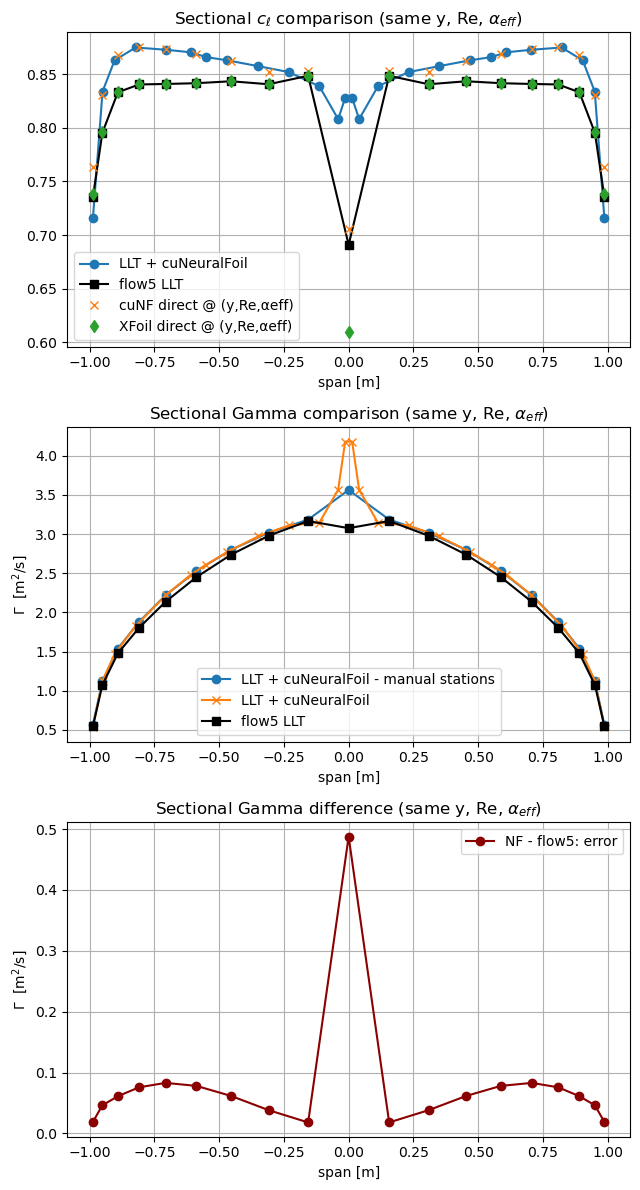

Direct cuNF - direct XFoil: mean = 0.02864217586115788  max abs = 0.09655807819366458


In [8]:
# ============================================================
# Compare sectional cl: LLT+cuNF vs flow5 LLT vs direct cuNF vs direct XFoil
# ============================================================

import numpy as np
import torch
import matplotlib.pyplot as plt

from cuneuralfoil.main import get_aero_from_kulfan_parameters_cuda

# ---- Exact points (y, Re, alpha_eff) ----
y_pts = np.array([
    0.987688, 0.951057, 0.891007, 0.809017, 0.707107, 0.587785, 0.453990,
    0.309017, 0.156434, -1.62e-15, -0.156434, -0.309017, -0.453990,
    -0.587785, -0.707107, -0.809017, -0.891007, -0.951057, -0.987688
], dtype=float)

Re_pts = np.array([
    98044.1, 179498, 236407, 286265, 338596, 388156, 432687,
    472086, 497546, 673333, 497546, 472086, 432687,
    388156, 338596, 286265, 236407, 179498, 98044.1
], dtype=float)

alpha_eff_pts = np.array([
    4.911406, 4.619285, 5.11422, 5.448696, 5.491642, 5.486928, 5.492498,
    5.407741, 5.53916, 4.40578, 5.53916, 5.407741, 5.492498,
    5.486928, 5.491642, 5.448696, 5.11422, 4.619285, 4.911406
], dtype=float)

# ---- Your direct XFoil cl at the same (y,Re,alpha_eff) points ----
cl_xfoil_direct = np.array([
    0.73824, 0.79613, 0.83336, 0.84059, 0.84090, 0.84175, 0.84360,
    0.84127, 0.84875, 0.60910, 0.84875, 0.84127, 0.84360,
    0.84175, 0.84090, 0.84059, 0.83336, 0.79613, 0.73824
], dtype=float)

# ---- Direct cuNeuralFoil batch evaluation (no LLT) ----
def eval_cuNF_CL(airfoil_cu, alpha_deg, Re, device="cpu", model_size="xlarge"):
    alpha_deg = np.asarray(alpha_deg, dtype=np.float32)
    Re = np.asarray(Re, dtype=np.float32)
    B = alpha_deg.shape[0]

    upper_base = airfoil_cu.upper_weights_cuda
    lower_base = airfoil_cu.lower_weights_cuda
    LE_base    = airfoil_cu.leading_edge_weight_cuda
    TE_base    = airfoil_cu.TE_thickness_cuda

    kulfan_batch = {
        "upper_weights_cuda": upper_base.unsqueeze(0).repeat(B, 1),
        "lower_weights_cuda": lower_base.unsqueeze(0).repeat(B, 1),
        "leading_edge_weight_cuda": LE_base.repeat(B),
        "TE_thickness_cuda": TE_base.repeat(B),
    }

    alpha_t = torch.as_tensor(alpha_deg, dtype=torch.float32, device=device)
    Re_t    = torch.as_tensor(Re,        dtype=torch.float32, device=device)

    with torch.no_grad():
        aero_t = get_aero_from_kulfan_parameters_cuda(
            kulfan_batch, alpha_t, Re_t, device=device, model_size=model_size
        )

    return aero_t["CL"].detach().cpu().numpy()

cl_cuNF_direct = eval_cuNF_CL(
    airfoil_cu=airfoil_cu,
    alpha_deg=alpha_eff_pts,
    Re=Re_pts,
    device=device,
    model_size=model_size,
)

nu = airflow["nu"]
chords=(Re_pts*nu)/V_inf_show

Gamma_from_cl_flow5=0.5*chords*V_inf_show*cl_xfoil_direct
Gamma_from_cl_nf=0.5*chords*V_inf_show*cl_cuNF_direct

# ---- Plot comparison ----
fig, ax = plt.subplots(3, 1, figsize=(6.5, 12))

# LLT + cuNF
ax[0].plot(y_mid, res["cl"], "-o", label="LLT + cuNeuralFoil")

# flow5 LLT
ax[0].plot(f5LLT_df["y(m)"], f5LLT_df["Cl"], "-s", color="black", label="flow5 LLT")

# direct cuNF at exact (y,Re,alpha_eff)
ax[0].plot(y_pts, cl_cuNF_direct, "x", label="cuNF direct @ (y,Re,αeff)")

# direct XFoil at exact (y,Re,alpha_eff)
ax[0].plot(y_pts, cl_xfoil_direct, "d", label="XFoil direct @ (y,Re,αeff)")

ax[0].set_title("Sectional $c_\\ell$ comparison (same y, Re, $\\alpha_{eff}$)")
axs[0].set_ylabel(r"$\Gamma$  [m$^2$/s]")
ax[0].set_xlabel("span [m]")
ax[0].grid(True)
ax[0].legend()

ax[1].plot(y_pts, Gamma_from_cl_nf, "-o", label="LLT + cuNeuralFoil - manual stations")
ax[1].plot(y_mid, res["Gamma"], "-x", label="LLT + cuNeuralFoil")
ax[1].plot(y_pts, Gamma_from_cl_flow5, "-s", color="black", label="flow5 LLT")
ax[1].set_title("Sectional Gamma comparison (same y, Re, $\\alpha_{eff}$)")
ax[1].set_ylabel(r"$\Gamma$  [m$^2$/s]")
ax[1].set_xlabel("span [m]")
ax[1].grid(True)
ax[1].legend()

ax[2].plot(y_pts, Gamma_from_cl_nf-Gamma_from_cl_flow5, "-o",color="#8B0000", label="NF - flow5: error")
ax[2].set_title("Sectional Gamma difference (same y, Re, $\\alpha_{eff}$)")
ax[2].set_ylabel(r"$\Gamma$  [m$^2$/s]")
ax[2].set_xlabel("span [m]")
ax[2].grid(True)
ax[2].legend()

plt.tight_layout()
plt.show()

# ---- Optional: numeric deltas at the exact points (cuNF vs XFoil) ----
diff_cu_xf = cl_cuNF_direct - cl_xfoil_direct
print("Direct cuNF - direct XFoil: mean =", float(np.mean(diff_cu_xf)),
      " max abs =", float(np.max(np.abs(diff_cu_xf))))
